# RQ3: Cross-policy inconsistency analysis

Reproduces every number reported in `Findings.tex` § *RQ3: Inconsistency analysis* and the two
panels of `fig_verdict_and_gdpr_v3.pdf`. Inputs are read from `data/dataset.tar.gz` (extracted on
first run).


## 1. Setup### 1.1 Decompress the bundled dataset

In [1]:
import tarfile
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR  = REPO_ROOT / 'data' / 'raw'
BUNDLE    = REPO_ROOT / 'data' / 'dataset.tar.gz'

DATA_DIR.mkdir(parents=True, exist_ok=True)
if (DATA_DIR / 'findings.csv').exists():
    print(f'Already extracted at {DATA_DIR}')
else:
    assert BUNDLE.exists(), f'Missing {BUNDLE}'
    print(f'Extracting {BUNDLE.name} ...')
    with tarfile.open(BUNDLE, 'r:gz') as tf:
        tf.extractall(DATA_DIR)
    print('Done.')


Already extracted at /srv/lustre01/project/vr_outsec-vh2sz1t4fks/users/soufiane.essahli/When-Policies-Disagree/data/raw


### 1.2 Imports and load

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

findings = pd.read_csv(DATA_DIR / 'findings.csv', low_memory=False)
wlb      = json.load(open(DATA_DIR / 'website_level_breakdown.json'))
gdi      = json.load(open(DATA_DIR / 'gdpr_disclosed_inc.json'))
canon    = json.load(open(DATA_DIR / 'canonical_qualifying.json'))

print(f'findings rows : {len(findings):,}')
print(f'total pairs   : {wlb["n_total_pairs"]:,}')
print(f'canonical FPs : {canon["fp_count"]:,}')
print(f'canonical TPs : {canon["tp_count"]:,}')


findings rows : 19,692
total pairs   : 5,372
canonical FPs : 3,067
canonical TPs : 1,122


## 2. Pair-level verdict mix

How the verifier resolves each (FP, TP) pair. Inconsistent + unspecified is the genuine-finding
rate referenced in §3.4.


In [3]:
n_pairs = wlb['n_total_pairs']
pv = wlb['pair_verdict_overall_counts']
for k in ('inconsistent', 'unspecified', 'non_conflict', 'no_finding'):
    print(f'  {k:14s}  {pv[k]:>5,}   ({pv[k]/n_pairs*100:5.1f}%)')
with_finding = sum(pv[k] for k in ('inconsistent', 'unspecified', 'non_conflict'))
genuine = pv['inconsistent'] + pv['unspecified']
print()
print(f'  pairs with any finding       {with_finding:>5,}   ({with_finding/n_pairs*100:5.1f}%)')
print(f'  pairs with genuine finding   {genuine:>5,}   ({genuine/n_pairs*100:5.1f}%)')


  inconsistent    3,471   ( 64.6%)
  unspecified        53   (  1.0%)
  non_conflict      330   (  6.1%)
  no_finding      1,518   ( 28.3%)

  pairs with any finding       3,854   ( 71.7%)
  pairs with genuine finding   3,524   ( 65.6%)


## 3. Pattern × verdict crosstab

Counts of *findings* (not pairs) by the four cross-policy patterns.


In [4]:
ct = pd.crosstab(findings['pattern_id'], findings['system_verdict'], margins=True, margins_name='all')
if 'inconsistent' in ct.columns:
    ct['inc%']  = (ct['inconsistent']/ct['all']*100).round(1)
if 'unspecified' in ct.columns:
    ct['unsp%'] = (ct['unspecified']/ct['all']*100).round(1)
print(ct.to_string())


system_verdict  inconsistent  non_conflict  unspecified    all  inc%  unsp%
pattern_id                                                                 
Π₁                      4557           918           17   5492  83.0    0.3
Π₂                      2517          2278           17   4812  52.3    0.4
Π₃                      4816          1001          147   5964  80.8    2.5
Π₄                       152          2839          433   3424   4.4   12.6
all                    12042          7036          614  19692  61.2    3.1


## 4. Heatmap — pair-level inconsistency by FP main-category × TP service-type

Right panel of `fig_verdict_and_gdpr_v3.pdf`. Cells with fewer than 5 pairs are masked out.


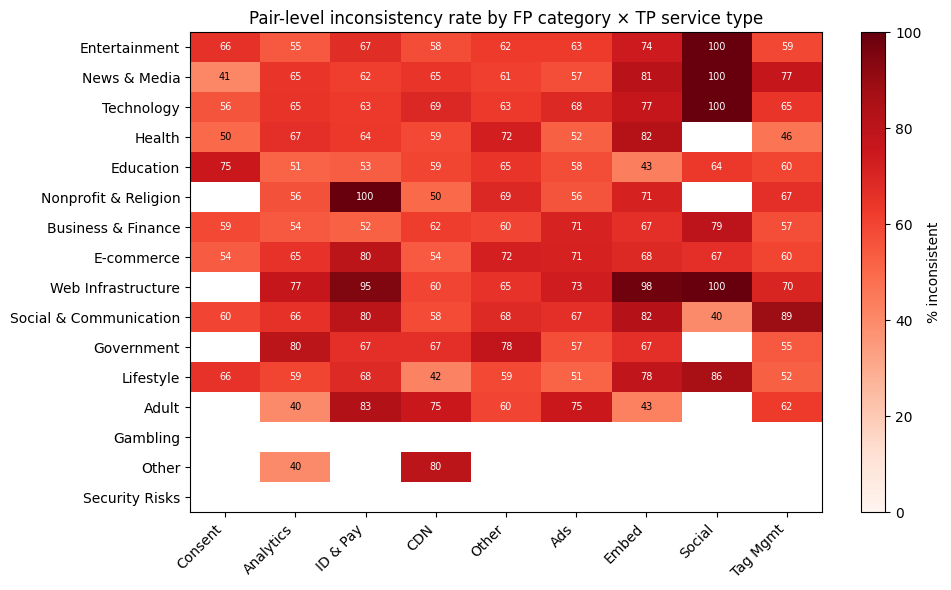

In [5]:
fp_cats = list(wlb['fp_cat_stats'].keys())
tp_buckets = list(wlb['tp_bucket_stats'].keys())
joint = wlb['joint_stats']

M = np.full((len(fp_cats), len(tp_buckets)), np.nan)
for key, st in joint.items():
    parts = [s.strip() for s in key.split('||')]
    if len(parts) != 2:
        continue
    fp, tp = parts
    if fp in fp_cats and tp in tp_buckets and st['n'] >= 5:
        M[fp_cats.index(fp), tp_buckets.index(tp)] = st['inconsistent'] / st['n'] * 100

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(M, cmap='Reds', vmin=0, vmax=100, aspect='auto')
ax.set_xticks(range(len(tp_buckets))); ax.set_xticklabels(tp_buckets, rotation=45, ha='right')
ax.set_yticks(range(len(fp_cats)));    ax.set_yticklabels(fp_cats)
for i in range(len(fp_cats)):
    for j in range(len(tp_buckets)):
        if not np.isnan(M[i, j]):
            ax.text(j, i, f'{M[i,j]:.0f}', ha='center', va='center',
                    color='white' if M[i,j] > 50 else 'black', fontsize=7)
fig.colorbar(im, ax=ax, label='% inconsistent')
ax.set_title('Pair-level inconsistency rate by FP category × TP service type')
plt.tight_layout()
fig.savefig(REPO_ROOT / 'notebooks' / 'figures' / 'rq3_heatmap.pdf')
fig.savefig(REPO_ROOT / 'notebooks' / 'figures' / 'rq3_heatmap.png', dpi=300)
plt.show()

## 5. Tag Management drill-down (61.9 %)

Among pairs whose third party is a tag manager, what fraction of *all* such pairs (including
no-finding pairs in the denominator) carry an inconsistent verdict.


In [6]:
tag, key = None, None
for k in wlb['tp_bucket_stats']:
    if 'tag' in k.lower():
        tag, key = wlb['tp_bucket_stats'][k], k
        break
if tag:
    rate = tag['inconsistent'] / tag['n']
    print(f'TP bucket: {key!r}')
    print(f'  total pairs    : {tag["n"]:,}')
    print(f'  inconsistent   : {tag["inconsistent"]:>4,}  ({rate*100:.1f}%)')
    print(f'  unspecified    : {tag["unspecified"]:>4,}')
    print(f'  non_conflict   : {tag["non_conflict"]:>4,}')
    print(f'  no_finding     : {tag["no_finding"]:>4,}')


TP bucket: 'Tag Mgmt'
  total pairs    : 669
  inconsistent   :  414  (61.9%)
  unspecified    :    3
  non_conflict   :   22
  no_finding     :  230


## 6. GDPR-category bar chart (left panel)

Per GDPR category, the share of pairs disclosing the category that the verifier flagged as
inconsistent.


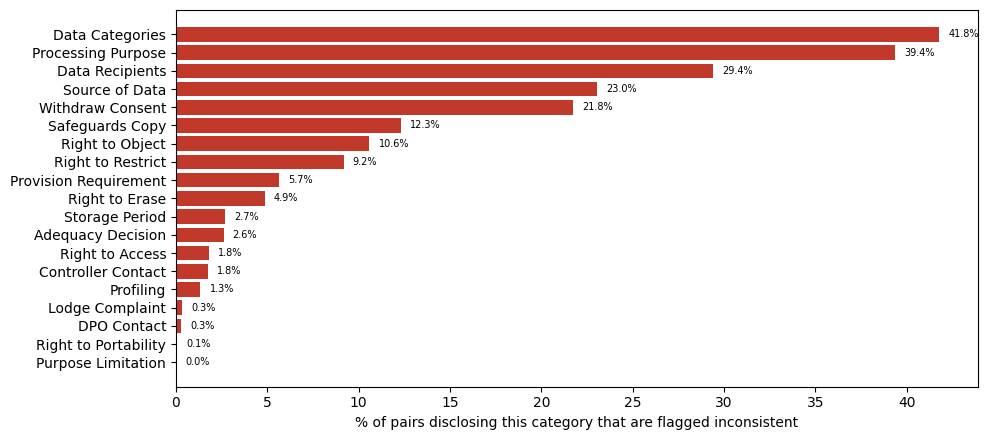

In [7]:
rows = sorted(gdi['rows'], key=lambda r: -r['pct_inc'])
labels = [r['category'] for r in rows]
pct_inc = [r['pct_inc'] for r in rows]
fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.barh(labels[::-1], pct_inc[::-1], color='#c0392b')
for b, p in zip(bars, pct_inc[::-1]):
    ax.text(p + 0.5, b.get_y() + b.get_height()/2, f'{p:.1f}%', va='center', fontsize=7)
ax.set_xlabel('% of pairs disclosing this category that are flagged inconsistent')
plt.tight_layout()
fig.savefig(REPO_ROOT / 'notebooks' / 'figures' / 'rq3_gdpr_inconsistency.pdf')
fig.savefig(REPO_ROOT / 'notebooks' / 'figures' / 'rq3_gdpr_inconsistency.png', dpi=300)
plt.show()

## 7. FP-level and TP-level inconsistency

What share of FPs (and TPs) in the analysis subset have at least one inconsistent pair.


In [8]:
import csv
pair_verdict = defaultdict(set)
for _, row in findings.iterrows():
    pair_verdict[row['pair_id']].add(row['system_verdict'])

from pathlib import Path as _P
import json as _json
pe = _json.load(open(DATA_DIR / 'pair_enrichment.json'))
all_pairs = list(pe.keys())

def split_pair(pid):
    return pid.split('__', 1) if '__' in pid else (None, None)

fp_verdicts = defaultdict(set)
tp_verdicts = defaultdict(set)
for pid in all_pairs:
    fp, tp = split_pair(pid)
    vs = pair_verdict.get(pid, {'no_finding'})
    if fp: fp_verdicts[fp].update(vs)
    if tp: tp_verdicts[tp].update(vs)

fp_with_inc = sum(1 for vs in fp_verdicts.values() if 'inconsistent' in vs)
tp_with_inc = sum(1 for vs in tp_verdicts.values() if 'inconsistent' in vs)
print(f'distinct FPs in pair set : {len(fp_verdicts):,}')
print(f'  with at least one inconsistency : {fp_with_inc:,}  ({fp_with_inc/len(fp_verdicts)*100:.1f}%)')
print(f'distinct TPs in pair set : {len(tp_verdicts):,}')
print(f'  with at least one inconsistency : {tp_with_inc:,}  ({tp_with_inc/len(tp_verdicts)*100:.1f}%)')


distinct FPs in pair set : 2,751
  with at least one inconsistency : 2,025  (73.6%)
distinct TPs in pair set : 542
  with at least one inconsistency : 413  (76.2%)


## 8. Sanity check vs. paper


In [9]:
checks = {
    'total pairs':                   (n_pairs, 5372),
    'inconsistent pairs':            (pv['inconsistent'], 3471),
    'unspecified pairs':             (pv['unspecified'],  53),
    'non_conflict pairs':            (pv['non_conflict'], 330),
    'no_finding pairs':              (pv['no_finding'],   1518),
    'distinct FPs in pair set':      (len(fp_verdicts), 2751),
    'distinct TPs in pair set':      (len(tp_verdicts), 542),
    'pct FPs with inconsistency':    (round(fp_with_inc/len(fp_verdicts)*100, 1), 73.6),
    'pct TPs with inconsistency':    (round(tp_with_inc/len(tp_verdicts)*100, 1), 76.2),
    'pct pairs inconsistent':        (round(pv['inconsistent']/n_pairs*100, 1), 64.6),
}
ok = True
for k, (v, expected) in checks.items():
    match = abs(v - expected) < 0.05 if isinstance(v, float) else v == expected
    print(f'  {k:32s}  {v}   (paper: {expected}, {"OK" if match else "MISMATCH"})')
    if not match: ok = False
print('\n' + ('PASSED' if ok else 'FAILED'))


  total pairs                       5372   (paper: 5372, OK)
  inconsistent pairs                3471   (paper: 3471, OK)
  unspecified pairs                 53   (paper: 53, OK)
  non_conflict pairs                330   (paper: 330, OK)
  no_finding pairs                  1518   (paper: 1518, OK)
  distinct FPs in pair set          2751   (paper: 2751, OK)
  distinct TPs in pair set          542   (paper: 542, OK)
  pct FPs with inconsistency        73.6   (paper: 73.6, OK)
  pct TPs with inconsistency        76.2   (paper: 76.2, OK)
  pct pairs inconsistent            64.6   (paper: 64.6, OK)

PASSED
